## 留意事項

- 本資料は教育・情報提供を目的とした検証資料であり、特定の暗号資産や取引手法の売買を推奨するものではありません。
- バックテストは過去データに基づく試算であり、将来の成果を保証しません。
- 手数料・スリッページ・板の順番・部分約定を完全には再現していません。
- ノートブックと圧縮CSVを同じフォルダへ置いて実行してください。


# 20260827 初心者botter会
## ETH/JPY 急落回復ロングbotの検証

bitbank現物ETH/JPYを対象に上昇トレンド中の急落を買い、短期反発を取る単純な回転戦略を検証します。

![botterkai](botterkai.jpeg)

## 0. 今日の流れ

```text
背景と問い
↓
仮説
↓
データ取得・品質チェック
↓
検証ロジック
↓
バックテスト
↓
仮説判定・実運用判定
↓
次の検証
```


## 1. 背景と問い
背景
1. ほへとさんの回転botを参考に、上昇局面で利益を取れるbotを作れないか考えた
https://note.com/hht/n/n63022edc4610
2. 上昇トレンド判定には200日移動平均線をつかうアイデア
3. 以下画像の赤枠の上昇をうまく取れないだろうか

問い
#### 上昇トレンド時、bitbankのETH/JPYで取引させた回転botは機能するか？

![bakutou](bakutou.png)

※ インジケーター（SMA）がなかったため移動平均チャネル（MAC）で代替

## 2. 仮説

### 上昇トレンド中の5%急落を買い、2%反発で売ると利益を得られる


## 3. 使用データと読み込み方法

| 項目 | 内容 |
|---|---|
| 元データ | bitbank Public APIのETH/JPY 1分足OHLCV |
| 共有データ | 1分足を5分足へ集約した圧縮CSV |
| ファイル | `eth_jpy_5min_2023-01-01_2026-08-01.csv.gz` |
| CSV期間 | 2023-01-01T00:00:00+00:00〜2026-08-01T23:55:00+00:00 |
| CSV行数 | 376,992行 |
| バックテスト開始 | 2024-01-01（日本時間） |
| 2023年 | SMA200計算のウォームアップ |
| SHA-256 | `c30c8710994e0da226f35b1cd02e68c5ac2564ed2aa37432ec036de324349985` |

```text
bitbank 1分足
↓ 5分足へ集約
圧縮CSVとして固定
↓
このノートブックでDataChecker
↓
SMA200・売買・成績をすべて再計算
```

CSVは取得元の変更や将来のデータ訂正で発表結果が変わらないよう、検証時点のスナップショットとして固定しています。


In [2]:
%matplotlib inline
from __future__ import annotations

from pathlib import Path
import hashlib
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib import font_manager
from IPython.display import display

DATA_FILENAME = "eth_jpy_5min_2023-01-01_2026-08-01.csv.gz"
EXPECTED_SHA256 = "c30c8710994e0da226f35b1cd02e68c5ac2564ed2aa37432ec036de324349985"
ANALYSIS_START = pd.Timestamp("2024-01-01 00:00", tz="Asia/Tokyo").tz_convert("UTC")
TZ = "Asia/Tokyo"
CAPITAL = 1_000_000.0
ALLOCATION = 0.75
MAKER_FEE = -0.0002
TAKER_FEE = 0.0012
TICK_SIZE = 1.0
QTY_STEP = 0.0001

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.unicode_minus"] = False
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
for name in ["Hiragino Sans", "YuGothic", "Meiryo", "AppleGothic", "DejaVu Sans"]:
    if name in available_fonts:
        plt.rcParams["font.family"] = [name]
        break

print("データファイル:", DATA_FILENAME)
print("分析開始:", ANALYSIS_START.tz_convert(TZ))


データファイル: eth_jpy_5min_2023-01-01_2026-08-01.csv.gz
分析開始: 2024-01-01 00:00:00+09:00


### データ品質チェック

以下は、ほへと先生のデータクレンジングを参考に以下8項目を実行します。

https://github.com/i-love-profit/crypto-data-analysis-course/blob/main/vol01_data_acquisition_and_cleansing.ipynb

1. 重複行
2. 時系列順
3. 欠損タイムスタンプ
4. NaN
5. 価格の妥当性
6. OHLC整合性
7. 50%超の急変動
8. 出来高ゼロの連続

`CRITICAL`の場合はバックテストを中断します。


In [3]:
"""
data_checker.py
===============
バックテスト前のデータ品質チェック & クレンジングモジュール。

使い方:
    from data_checker import check_and_clean

    df_clean, report = check_and_clean(df)
    print(report.summary())

対応データソース: Binance, yfinance, その他任意のOHLCV DataFrame
"""

from __future__ import annotations

import pandas as pd
import numpy as np
from dataclasses import dataclass, field
from typing import Optional


# ============================================================
# 設定
# ============================================================

# 各データソースの代表的なカラム名 → 内部正規名（open/high/low/close/volume）へのマッピング
COLUMN_ALIASES: dict[str, str] = {
    # 小文字
    "open": "open", "high": "high", "low": "low", "close": "close", "volume": "volume",
    # 大文字
    "Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume",
    # yfinance MultiIndex など
    "Adj Close": "close",
}

# デフォルト閾値
DEFAULT_EXTREME_RET        = 0.50  # 1足で50%超の変動 → データ異常とみなす
DEFAULT_MIN_PRICE          = 0.0   # 価格がこれ以下 → 異常
DEFAULT_MAX_CONSEC_ZERO_VOL = 3    # 出来高ゼロがこの本数以上連続 → 警告


# ============================================================
# レポートクラス
# ============================================================

@dataclass
class CheckItem:
    name: str
    level: str          # "OK" / "WARNING" / "CRITICAL"
    detail: str
    n_affected: int = 0
    fixed: bool = False
    fix_detail: str = ""


@dataclass
class CheckReport:
    source_name: str = ""
    original_rows: int = 0
    cleaned_rows: int = 0
    items: list[CheckItem] = field(default_factory=list)

    def add(self, item: CheckItem) -> None:
        self.items.append(item)

    # 最悪レベルを返す
    @property
    def worst_level(self) -> str:
        levels = [i.level for i in self.items]
        if "CRITICAL" in levels:
            return "CRITICAL"
        if "WARNING" in levels:
            return "WARNING"
        return "OK"

    def summary(self) -> str:
        lines = [
            "=" * 60,
            f"DataChecker レポート  [{self.source_name}]",
            "=" * 60,
            f"元データ行数:     {self.original_rows:,}",
            f"クレンジング後:   {self.cleaned_rows:,}",
            f"総合判定:         {self.worst_level}",
            "-" * 60,
        ]
        for item in self.items:
            icon = {"OK": "✅", "WARNING": "⚠️ ", "CRITICAL": "❌"}.get(item.level, "")
            lines.append(f"{icon} [{item.level:<8}] {item.name}")
            lines.append(f"           {item.detail}")
            if item.fixed:
                lines.append(f"           → 修正済み: {item.fix_detail}")
        lines.append("=" * 60)
        return "\n".join(lines)


# ============================================================
# 内部ユーティリティ
# ============================================================

def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    """カラム名を open/high/low/close/volume に正規化する。"""
    rename = {}
    for col in df.columns:
        normalized = COLUMN_ALIASES.get(str(col))
        if normalized:
            rename[col] = normalized
    return df.rename(columns=rename)


def _infer_freq(df: pd.DataFrame) -> Optional[pd.Timedelta]:
    """インデックスから時間足（最頻の間隔）を推定する。"""
    if len(df) < 2:
        return None
    diffs = pd.Series(df.index).diff().dropna()
    return diffs.mode().iloc[0] if not diffs.empty else None


# ============================================================
# メイン関数
# ============================================================

def check_and_clean(
    df: pd.DataFrame,
    source_name: str = "unknown",
    extreme_ret_threshold: float = DEFAULT_EXTREME_RET,
    min_price: float = DEFAULT_MIN_PRICE,
    max_consec_zero_vol: int = DEFAULT_MAX_CONSEC_ZERO_VOL,
    auto_fix: bool = True,
) -> tuple[pd.DataFrame, CheckReport]:
    """
    OHLCVデータの品質チェック & クレンジングを実行する。

    Parameters
    ----------
    df : pd.DataFrame
        OHLCVデータ。インデックスは DatetimeIndex 推奨。
        カラム名は大文字・小文字どちらでも可。
    source_name : str
        レポートに表示するデータ名（例: "BTCUSDT_1h_binance"）。
    extreme_ret_threshold : float
        この変動率を超えたら「データ異常」とみなす（デフォルト 0.50 = 50%）。
    min_price : float
        価格がこれ以下の行を異常とみなす（デフォルト 0）。
    max_consec_zero_vol : int
        出来高ゼロがこの本数以上連続したら警告（デフォルト 3）。
    auto_fix : bool
        True の場合、WARNING レベルの問題は自動修正する。

    Returns
    -------
    df_clean : pd.DataFrame
        クレンジング済みデータ（問題がなければ元データのコピー）。
    report : CheckReport
        チェック結果の詳細レポート。
    """
    df = df.copy()
    df = _normalize_columns(df)

    price_cols = [c for c in ["open", "high", "low", "close"] if c in df.columns]
    has_volume = "volume" in df.columns

    report = CheckReport(
        source_name=source_name,
        original_rows=len(df),
    )

    # ----------------------------------------------------------
    # チェック1: 重複インデックス
    # ----------------------------------------------------------
    n_dup = df.index.duplicated().sum()
    if n_dup == 0:
        report.add(CheckItem("重複行", "OK", f"重複なし"))
    else:
        item = CheckItem("重複行", "WARNING", f"{n_dup} 件の重複インデックスを検出", n_affected=n_dup)
        if auto_fix:
            df = df[~df.index.duplicated(keep="first")]
            item.fixed = True
            item.fix_detail = "最初の出現を残して除去"
        report.add(item)

    # ----------------------------------------------------------
    # チェック2: インデックスのソート順
    # ----------------------------------------------------------
    if not df.index.is_monotonic_increasing:
        item = CheckItem("時系列順", "WARNING", "インデックスが昇順になっていない")
        if auto_fix:
            df = df.sort_index()
            item.fixed = True
            item.fix_detail = "昇順にソート"
        report.add(item)
    else:
        report.add(CheckItem("時系列順", "OK", "昇順で整列済み"))

    # ----------------------------------------------------------
    # チェック3: 欠損タイムスタンプ（Vol.01ノートブックと同じ reindex 方式）
    # ※ 24/7取引所（Binance等）向け。CMEなど休場のある取引所では誤検知あり。
    # ----------------------------------------------------------
    freq = _infer_freq(df)
    if freq is not None and isinstance(df.index, pd.DatetimeIndex):
        expected = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq)
        missing_ts = expected.difference(df.index)
        n_missing = len(missing_ts)
        if n_missing == 0:
            report.add(CheckItem("欠損タイムスタンプ", "OK", f"欠損なし（推定時間足: {freq}）"))
        else:
            item = CheckItem(
                "欠損タイムスタンプ", "WARNING",
                f"{n_missing} 本の足が欠損（推定時間足: {freq}）",
                n_affected=n_missing,
            )
            if auto_fix and price_cols:
                df = df.reindex(expected)
                df[price_cols] = df[price_cols].ffill()
                if has_volume:
                    df["volume"] = df["volume"].fillna(0)
                item.fixed = True
                item.fix_detail = "完全インデックスで reindex → 価格: ffill、出来高: 0補完"
            report.add(item)
    else:
        report.add(CheckItem("欠損タイムスタンプ", "OK", "インデックスが DatetimeIndex でないためスキップ"))

    # ----------------------------------------------------------
    # チェック4: NaN値
    # ----------------------------------------------------------
    n_nan = df[price_cols].isnull().sum().sum() if price_cols else 0
    if n_nan == 0:
        report.add(CheckItem("NaN値", "OK", "価格列に NaN なし"))
    else:
        item = CheckItem("NaN値", "WARNING", f"価格列に {n_nan} 件の NaN", n_affected=n_nan)
        if auto_fix and price_cols:
            df[price_cols] = df[price_cols].ffill()
            item.fixed = True
            item.fix_detail = "ffill で補完"
        report.add(item)

    # ----------------------------------------------------------
    # チェック5: 価格の妥当性（ゼロ・マイナス）
    # ----------------------------------------------------------
    if price_cols:
        invalid_price = (df[price_cols] <= min_price).any(axis=1)
        n_inv = invalid_price.sum()
        if n_inv == 0:
            report.add(CheckItem("価格妥当性", "OK", f"価格 > {min_price} を確認"))
        else:
            item = CheckItem(
                "価格妥当性", "CRITICAL",
                f"{n_inv} 行で価格が {min_price} 以下（取引所バグ・データ欠損の可能性）",
                n_affected=n_inv,
            )
            if auto_fix:
                df.loc[invalid_price, price_cols] = np.nan
                df[price_cols] = df[price_cols].ffill()
                item.fixed = True
                item.fix_detail = "NaN 化 → ffill で補完"
            report.add(item)

    # ----------------------------------------------------------
    # チェック6: OHLC整合性（High >= Low）
    # ----------------------------------------------------------
    if all(c in df.columns for c in ["high", "low"]):
        bad_ohlc = (df["high"] < df["low"]).sum()
        if bad_ohlc == 0:
            report.add(CheckItem("OHLC整合性", "OK", "high >= low を確認"))
        else:
            item = CheckItem(
                "OHLC整合性", "CRITICAL",
                f"{bad_ohlc} 行で high < low（データ破損の疑い）",
                n_affected=bad_ohlc,
            )
            if auto_fix:
                mask = df["high"] < df["low"]
                df.loc[mask, ["high", "low"]] = np.nan
                df[["high", "low"]] = df[["high", "low"]].ffill()
                item.fixed = True
                item.fix_detail = "該当行を NaN 化 → ffill で補完"
            report.add(item)

    # ----------------------------------------------------------
    # チェック7: 急変動（±extreme_ret_threshold 超）
    # ----------------------------------------------------------
    if "close" in df.columns:
        ret = df["close"].pct_change()
        extreme_mask = ret.abs() > extreme_ret_threshold
        n_extreme = extreme_mask.sum()
        if n_extreme == 0:
            report.add(CheckItem(
                "急変動チェック", "OK",
                f"±{extreme_ret_threshold*100:.0f}% 超の変動なし",
            ))
        else:
            pct = extreme_ret_threshold * 100
            item = CheckItem(
                "急変動チェック", "CRITICAL",
                f"{n_extreme} 行で ±{pct:.0f}% 超の変動（取引所障害・フラッシュクラッシュの可能性）",
                n_affected=n_extreme,
            )
            if auto_fix:
                df.loc[extreme_mask, price_cols] = np.nan
                df[price_cols] = df[price_cols].ffill()
                item.fixed = True
                item.fix_detail = "該当行を NaN 化 → ffill で補完（要目視確認）"
            report.add(item)

    # ----------------------------------------------------------
    # チェック8: 出来高ゼロの連続
    # ----------------------------------------------------------
    if has_volume:
        is_zero = (df["volume"] == 0).astype(int)
        consec = is_zero.groupby((is_zero != is_zero.shift()).cumsum()).transform("sum")
        max_consec = int(consec.max()) if len(consec) > 0 else 0
        n_zero = (df["volume"] == 0).sum()

        if max_consec < max_consec_zero_vol:
            report.add(CheckItem(
                "出来高ゼロ連続", "OK",
                f"出来高ゼロ連続の最大: {max_consec} 本（閾値: {max_consec_zero_vol}）",
            ))
        else:
            report.add(CheckItem(
                "出来高ゼロ連続", "WARNING",
                f"出来高ゼロが {max_consec} 本連続（取引停止・欠損の可能性）。"
                f"合計 {n_zero} 本がゼロ。手動確認を推奨。",
                n_affected=n_zero,
            ))

    report.cleaned_rows = len(df)
    return df, report


In [4]:
candidates = [
    Path.cwd() / DATA_FILENAME,
    Path.cwd() / "ETHJPY急落回復ロング_共有用" / DATA_FILENAME,
]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"{DATA_FILENAME} が見つかりません。ノートブックと同じフォルダへ置いてください。"
    )

actual_sha256 = hashlib.sha256(data_path.read_bytes()).hexdigest()
if actual_sha256 != EXPECTED_SHA256:
    raise RuntimeError(
        "圧縮CSVのSHA-256が一致しません。配布ファイルを再取得してください。\n"
        f"expected={EXPECTED_SHA256}\nactual={actual_sha256}"
    )

loaded = pd.read_csv(data_path, compression="gzip")
required = ["timestamp", "open", "high", "low", "close", "volume"]
missing = [column for column in required if column not in loaded.columns]
if missing:
    raise ValueError(f"必要列がありません: {missing}")
loaded["timestamp"] = pd.to_datetime(loaded["timestamp"], utc=True)
bars = loaded.set_index("timestamp")[["open", "high", "low", "close", "volume"]]
for column in bars.columns:
    bars[column] = pd.to_numeric(bars[column], errors="raise")
bars, report_5min = check_and_clean(
    bars,
    source_name="bitbank_eth_jpy_5min_compressed_csv",
)
print(report_5min.summary())
if report_5min.worst_level == "CRITICAL":
    raise RuntimeError("5分足データ品質がCRITICALのため検証を中断します")

print("SHA-256: OK")
print(f"読込完了: {len(bars):,}行")
print("期間:", bars.index.min(), "〜", bars.index.max())


DataChecker レポート  [bitbank_eth_jpy_5min_compressed_csv]
元データ行数:     376,992
クレンジング後:   376,992
総合判定:         WARNING
------------------------------------------------------------
✅ [OK      ] 重複行
           重複なし
✅ [OK      ] 時系列順
           昇順で整列済み
✅ [OK      ] 欠損タイムスタンプ
           欠損なし（推定時間足: 0 days 00:05:00）
✅ [OK      ] NaN値
           価格列に NaN なし
✅ [OK      ] 価格妥当性
           価格 > 0.0 を確認
✅ [OK      ] OHLC整合性
           high >= low を確認
✅ [OK      ] 急変動チェック
           ±50% 超の変動なし
⚠️  [WARNING ] 出来高ゼロ連続
           出来高ゼロが 89 本連続（取引停止・欠損の可能性）。合計 10903 本がゼロ。手動確認を推奨。
SHA-256: OK
読込完了: 376,992行
期間: 2023-01-01 00:00:00+00:00 〜 2026-08-01 23:55:00+00:00


## 4. 検証ロジック

| 項目 | 条件 |
|---|---|
| 市場 | bitbank現物 ETH/JPY |
| 判定足 | 日足で相場判定、5分足で売買判定 |
| トレンド | 前日終値 > SMA200、かつSMA200が前日比で上昇 |
| 買い | 直前24本の確定5分足高値の最大値 × 0.95 |
| 配分 | 総資産の75% |
| ポジション | 同時に1つ、買い増しなし |
| 通常売却 | 平均買値 +2% |
| 3日後 | 最低利確率を+0.5%へ変更 |
| 14日後 | 5分足終値で全量決済 |
| トレンドOFF | 新規買いのみ停止。保有玉はそれだけで決済しない |
| 約定 | 出来高が正で、5分足の安値・高値が指値へ到達した場合 |
| 同一足 | 買った5分足では売らず、次の足から売却判定 |
| 手数料設定 | メイカー −0.02%、14日決済のテイカー 0.12% |

資金75%は利益を最大化して選んだ値ではなく、25%を現金として残す暫定的なリスク管理です。

bitbank公式: [手数料](https://bitbank.cc/docs/fees/)・[Post Only](https://support.bitbank.cc/hc/ja/articles/900005145623--%E5%8F%96%E5%BC%95%E6%89%80-Post-Only%E3%81%A8%E3%81%AF%E3%81%AA%E3%82%93%E3%81%A7%E3%81%99%E3%81%8B)


In [5]:
def floor_tick(value: float) -> float:
    return math.floor(value / TICK_SIZE + 1e-12) * TICK_SIZE


def ceil_tick(value: float) -> float:
    return math.ceil(value / TICK_SIZE - 1e-12) * TICK_SIZE


def floor_qty(value: float) -> float:
    return math.floor(value / QTY_STEP + 1e-12) * QTY_STEP


def build_regime_allow(frame: pd.DataFrame):
    local = frame.tz_convert(TZ)
    daily_close = local["close"].resample("1D").last().dropna()
    sma200 = daily_close.rolling(200, min_periods=200).mean()
    raw_regime = (daily_close > sma200) & (sma200 > sma200.shift(1))
    allow_next_day = raw_regime.shift(1).astype("boolean")
    allow = (
        allow_next_day.reindex(local.index, method="ffill")
        .fillna(False)
        .to_numpy(dtype=bool)
    )
    daily = pd.DataFrame({
        "close": daily_close,
        "sma200": sma200,
        "raw_regime": raw_regime,
        "allow": allow_next_day.fillna(False),
    })
    return allow, daily


def backtest(frame, allow, max_days=None, soft_after_days=None, soft_tp_pct=None):
    opens = frame["open"].to_numpy(float)
    highs = frame["high"].to_numpy(float)
    lows = frame["low"].to_numpy(float)
    closes = frame["close"].to_numpy(float)
    volumes = frame["volume"].to_numpy(float)
    index = frame.index
    rolling_high = frame["high"].rolling(24).max().shift(1).to_numpy()
    rolling_low = frame["low"].rolling(1).min().shift(1).to_numpy()
    start_i = 25

    cash = CAPITAL
    base = cash
    qty = 0.0
    avg = 0.0
    entry_time = None
    cycle = 0
    trades = []
    equity_times = [index[start_i - 1]]
    equity_values = [cash]
    max_delta = pd.Timedelta(days=max_days) if max_days is not None else None
    soft_delta = pd.Timedelta(days=soft_after_days) if soft_after_days is not None else None

    def sell_all(i, price, reason, fee_rate):
        nonlocal cash, base, qty, avg, entry_time
        old_avg = avg
        notional = qty * price
        fee = notional * fee_rate
        cash += notional - fee
        pnl = cash - base
        trades.append({
            "cycle": cycle,
            "entry": entry_time,
            "exit": index[i],
            "avg": old_avg,
            "px": price,
            "qty": qty,
            "pnl": pnl,
            "ret": pnl / base,
            "reason": reason,
        })
        qty = 0.0
        avg = 0.0
        entry_time = None
        base = cash

    for i in range(start_i, len(frame)):
        if np.isnan(rolling_high[i]) or np.isnan(rolling_low[i]):
            continue
        can_fill = np.isfinite(volumes[i]) and volumes[i] > 0
        closed_this_bar = False

        if qty > 0 and can_fill:
            held_for = index[i] - entry_time
            active_tp = 2.0
            if soft_delta is not None and held_for >= soft_delta:
                active_tp = float(soft_tp_pct)
            target = max(
                ceil_tick(rolling_low[i]),
                ceil_tick(avg * (1 + active_tp / 100)),
            )
            if highs[i] >= target:
                sell_all(i, max(opens[i], target), "target", MAKER_FEE)
                closed_this_bar = True
            elif max_delta is not None and held_for >= max_delta:
                sell_all(i, closes[i], "time_stop", TAKER_FEE)
                closed_this_bar = True

        if not closed_this_bar and allow[i] and cash > 0 and can_fill:
            buy_limit = floor_tick(rolling_high[i] * 0.95)
            if qty == 0 and buy_limit > 0 and lows[i] <= buy_limit:
                buy_price = min(opens[i], buy_limit)
                base = cash
                entry_time = index[i]
                cycle += 1
                target_qty = base * ALLOCATION / buy_price
                affordable = cash / buy_price
                add_qty = floor_qty(min(target_qty, affordable))
                if add_qty >= QTY_STEP:
                    notional = add_qty * buy_price
                    fee = notional * MAKER_FEE
                    cash -= notional + fee
                    avg = buy_price
                    qty = add_qty

        equity_times.append(index[i])
        equity_values.append(max(cash + qty * closes[i], 0.0))

    return {
        "trades": pd.DataFrame(trades),
        "equity": pd.Series(equity_values, index=equity_times, name="equity_jpy"),
        "open_position": qty > 0,
    }


allow_full, daily = build_regime_allow(bars)
mask = bars.index >= ANALYSIS_START
test = bars.loc[mask].copy()
allow = allow_full[mask]

baseline = backtest(test, allow)
adopted = backtest(
    test,
    allow,
    max_days=14,
    soft_after_days=3,
    soft_tp_pct=0.5,
)
print("検証期間:", test.index.min().tz_convert(TZ), "〜", test.index.max().tz_convert(TZ))
print("5分足:", f"{len(test):,}本")


検証期間: 2024-01-01 00:00:00+09:00 〜 2026-08-02 08:55:00+09:00
5分足: 271,980本


## 5. 評価方法

### 急落後に反発するか

- +2%へ1日、3日、14日以内に到達した割合
- +2%到達までの時間
- 到達または14日経過までの最大逆行率（MAE）

### botとして利益が出るか

- 累積リターン、最大ドローダウン
- 取引数、勝率、保有期間、14日決済回数
- 14日上限あり、時間上限なし、75% HODLとの比較
- 年別成績


## 6. 評価基準

- **運用成績**：75% HODLを上回り、最大ドローダウンが20%以内
- **実運用候補**：未使用期間で30件以上を観測し、上記を再現

## 7. 検証結果

### botの運用成績

In [6]:
def enrich_trades(result, label):
    rows = []
    for trade in result["trades"].to_dict("records"):
        entry = pd.Timestamp(trade["entry"])
        exit_ = pd.Timestamp(trade["exit"])
        segment = test.loc[entry:exit_]
        row = dict(trade)
        row.update({
            "variant": label,
            "holding_hours": (exit_ - entry).total_seconds() / 3600,
            "mae_pct": (segment["low"].min() / trade["avg"] - 1) * 100,
            "mfe_pct": (segment["high"].max() / trade["avg"] - 1) * 100,
            "entry_year": entry.tz_convert(TZ).year,
        })
        rows.append(row)
    return pd.DataFrame(rows)


def summary_row(result, trades, label):
    equity = result["equity"]
    drawdown = equity / equity.cummax() - 1
    wins = int(trades["pnl"].gt(0).sum())
    return {
        "仕様": label,
        "累積リターン%": (equity.iloc[-1] / CAPITAL - 1) * 100,
        "最大DD%": drawdown.min() * 100,
        "取引数": len(trades),
        "勝率%": wins / len(trades) * 100,
        "保有中央値日": trades["holding_hours"].median() / 24,
        "最長保有日": trades["holding_hours"].max() / 24,
        "14日決済": int(trades["reason"].eq("time_stop").sum()),
        "未決済": result["open_position"],
    }


baseline_trades = enrich_trades(baseline, "時間上限なし")
adopted_trades = enrich_trades(adopted, "14日上限あり")
summary = pd.DataFrame([
    summary_row(adopted, adopted_trades, "14日上限あり"),
    summary_row(baseline, baseline_trades, "時間上限なし"),
])

start_close = test["close"].iloc[0]
hodl = CAPITAL * (1 - ALLOCATION) + CAPITAL * ALLOCATION * test["close"] / start_close
hodl_return = (hodl.iloc[-1] / CAPITAL - 1) * 100
display(summary.round(2))
print(f"資金75% HODL: {hodl_return:+.2f}%")


,仕様,累積リターン%,最大DD%,取引数,勝率%,保有中央値日,最長保有日,14日決済,未決済
0,14日上限あり,73.20,-14.30,43,97.67,0.12,14.00,1,False
1,時間上限なし,89.24,-47.41,42,100.00,0.13,193.84,0,False


資金75% HODL: -7.99%


### 急落後の+2%到達率


,期間,件数,1日以内%,3日以内%,14日以内%,到達時間中央値h,MAE中央値%,最悪MAE%
0,全期間,43,74.42,90.70,93.02,2.29,-1.03,-19.29
1,2024,27,77.78,96.30,96.30,1.33,-1.21,-12.29
2,2025,16,68.75,81.25,87.50,4.08,-1.00,-19.29


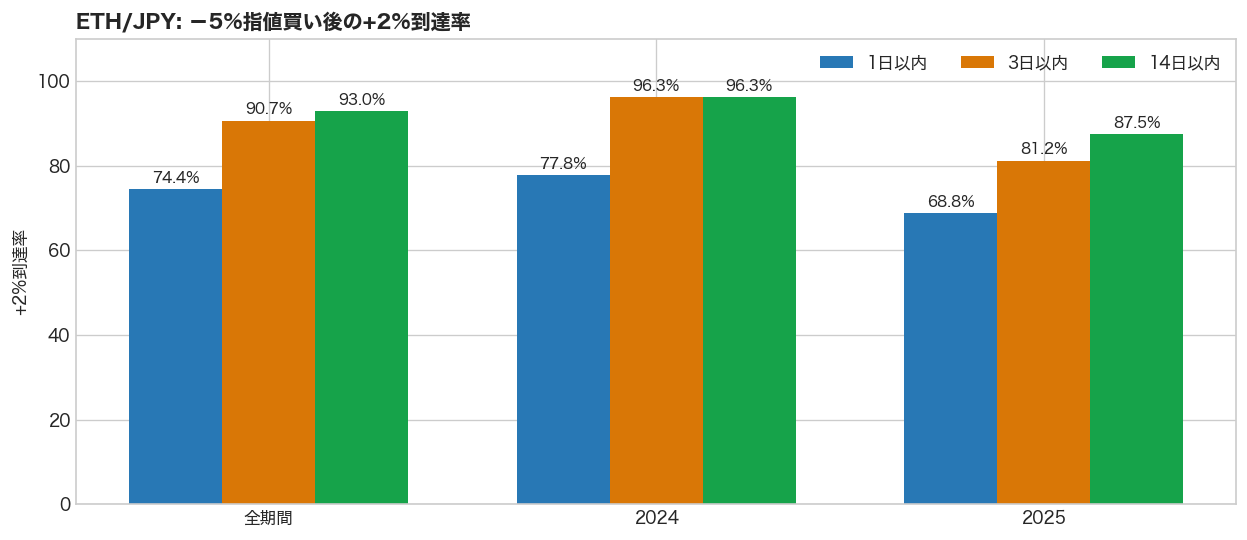

In [7]:
def make_event_detail(trades):
    rows = []
    index = test.index
    for trade in trades.to_dict("records"):
        entry = pd.Timestamp(trade["entry"])
        avg = float(trade["avg"])
        target = avg * 1.02
        left = int(index.searchsorted(entry, side="left"))
        after = test.iloc[left + 1:]
        observation = after.loc[after.index <= entry + pd.Timedelta(days=14)]
        hits = observation.index[observation["high"].ge(target)]
        first_hit = hits[0] if len(hits) else pd.NaT
        row = {
            "cycle": int(trade["cycle"]),
            "entry": entry,
            "entry_year": int(entry.tz_convert(TZ).year),
            "strategy_exit_reason": trade["reason"],
            "strategy_return_pct": trade["ret"] * 100,
            "first_hit": first_hit,
            "hours_to_2pct": (first_hit - entry).total_seconds() / 3600 if pd.notna(first_hit) else np.nan,
        }
        for label, days in [("1d", 1), ("3d", 3), ("14d", 14)]:
            end = entry + pd.Timedelta(days=days)
            future = after.loc[after.index <= end]
            conservative = test.iloc[left:].loc[test.iloc[left:].index <= end]
            row[f"hit_{label}"] = bool(future["high"].ge(target).any())
            row[f"mae_{label}_pct"] = (conservative["low"].min() / avg - 1) * 100
        outcome_end = first_hit if pd.notna(first_hit) else entry + pd.Timedelta(days=14)
        path = test.iloc[left:].loc[test.iloc[left:].index <= outcome_end]
        row["mae_before_outcome_pct"] = (path["low"].min() / avg - 1) * 100
        rows.append(row)
    return pd.DataFrame(rows)


def event_summary_rows(events):
    rows = []
    groups = [("全期間", events)] + [(str(y), g) for y, g in events.groupby("entry_year")]
    for period, group in groups:
        hit_hours = group.loc[group["hit_14d"], "hours_to_2pct"]
        rows.append({
            "期間": period,
            "件数": len(group),
            "1日以内%": group["hit_1d"].mean() * 100,
            "3日以内%": group["hit_3d"].mean() * 100,
            "14日以内%": group["hit_14d"].mean() * 100,
            "到達時間中央値h": hit_hours.median(),
            "MAE中央値%": group["mae_before_outcome_pct"].median(),
            "最悪MAE%": group["mae_before_outcome_pct"].min(),
        })
    return pd.DataFrame(rows)


events = make_event_detail(adopted_trades)
event_summary = event_summary_rows(events)
display(event_summary.round(2))

fig, ax = plt.subplots(figsize=(10.5, 4.6))
x = np.arange(len(event_summary))
width = 0.24
for offset, column, label, color in [
    (-1, "1日以内%", "1日以内", "#2878b5"),
    (0, "3日以内%", "3日以内", "#d97706"),
    (1, "14日以内%", "14日以内", "#16a34a"),
]:
    rectangles = ax.bar(x + offset * width, event_summary[column], width, label=label, color=color)
    ax.bar_label(rectangles, fmt="%.1f%%", padding=2, fontsize=9)
ax.set_xticks(x, event_summary["期間"])
ax.set_ylim(0, 110)
ax.set_ylabel("+2%到達率")
ax.set_title("ETH/JPY: −5%指値買い後の+2%到達率", loc="left", weight="bold")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


### 価格・売買位置・資産曲線

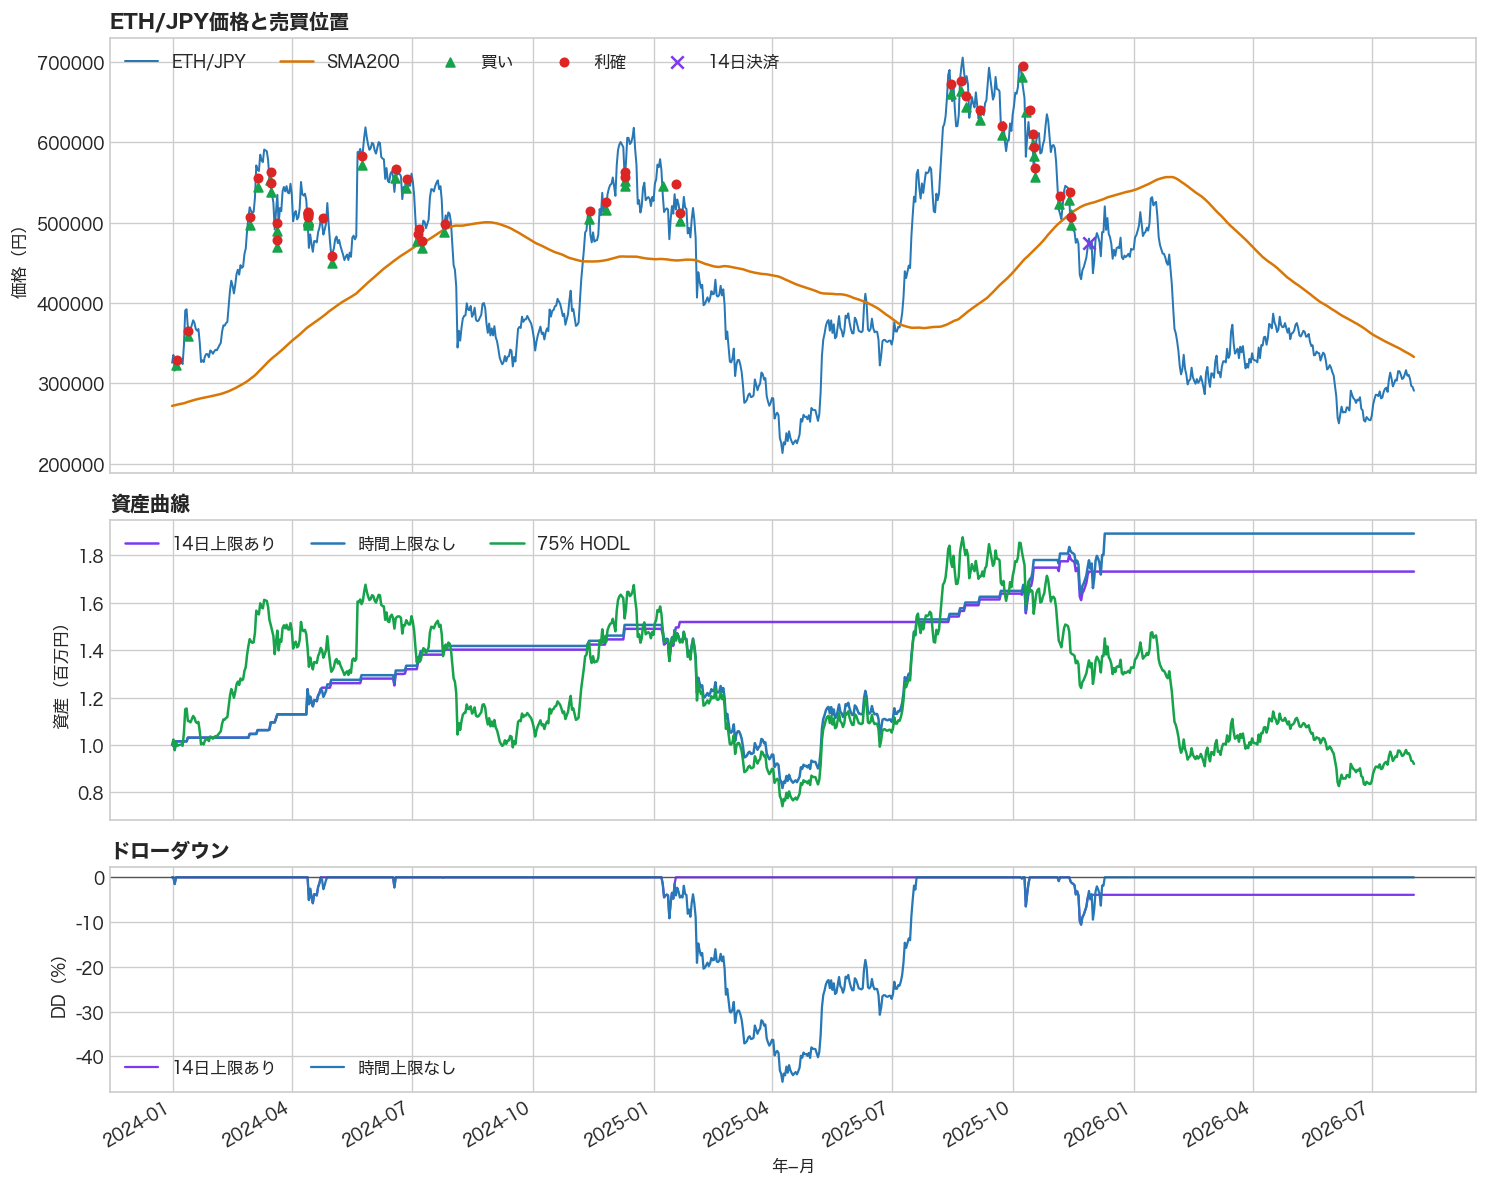

In [8]:
local_equity = pd.DataFrame({
    "14日上限あり": adopted["equity"],
    "時間上限なし": baseline["equity"],
    "75% HODL": hodl,
}).tz_convert(TZ).resample("1D").last().ffill()
daily_view = daily.loc[
    local_equity.index.min().date().isoformat():local_equity.index.max().date().isoformat()
]
markers = adopted_trades.copy()
markers["entry"] = pd.to_datetime(markers["entry"], utc=True).dt.tz_convert(TZ)
markers["exit"] = pd.to_datetime(markers["exit"], utc=True).dt.tz_convert(TZ)

fig, axes = plt.subplots(
    3, 1, figsize=(12.5, 10), sharex=True,
    gridspec_kw={"height_ratios": [1.45, 1, 0.75]},
)
ax = axes[0]
ax.plot(daily_view.index, daily_view["close"], color="#2878b5", lw=1.2, label="ETH/JPY")
ax.plot(daily_view.index, daily_view["sma200"], color="#d97706", lw=1.5, label="SMA200")
ax.scatter(markers["entry"], markers["avg"], marker="^", s=28, color="#16a34a", label="買い", zorder=4)
normal = markers[markers["reason"].eq("target")]
timed = markers[markers["reason"].eq("time_stop")]
ax.scatter(normal["exit"], normal["px"], marker="o", s=25, color="#dc2626", label="利確", zorder=4)
ax.scatter(timed["exit"], timed["px"], marker="x", s=55, color="#7c3aed", label="14日決済", zorder=5)
ax.set_ylabel("価格（円）")
ax.set_title("ETH/JPY価格と売買位置", loc="left", weight="bold")
ax.legend(ncol=5, loc="upper left")

colors = {"14日上限あり": "#7c3aed", "時間上限なし": "#2878b5", "75% HODL": "#16a34a"}
ax = axes[1]
for column in ["14日上限あり", "時間上限なし", "75% HODL"]:
    ax.plot(local_equity.index, local_equity[column] / 1_000_000, lw=1.5, color=colors[column], label=column)
ax.set_ylabel("資産（百万円）")
ax.set_title("資産曲線", loc="left", weight="bold")
ax.legend(ncol=3, loc="upper left")

ax = axes[2]
for column in ["14日上限あり", "時間上限なし"]:
    values = local_equity[column]
    dd = (values / values.cummax() - 1) * 100
    ax.plot(local_equity.index, dd, lw=1.35, color=colors[column], label=column)
ax.axhline(0, color="#555", lw=0.8)
ax.set_ylabel("DD（%）")
ax.set_xlabel("年−月")
ax.set_title("ドローダウン", loc="left", weight="bold")
ax.legend(ncol=2, loc="lower left")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m", tz=local_equity.index.tz))
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 年別成績


仕様,14日上限あり,時間上限なし,75% HODL
年,,,
2024,49.02,50.69,47.67
2025,16.23,25.58,-10.26
2026,0.00,0.00,-30.57


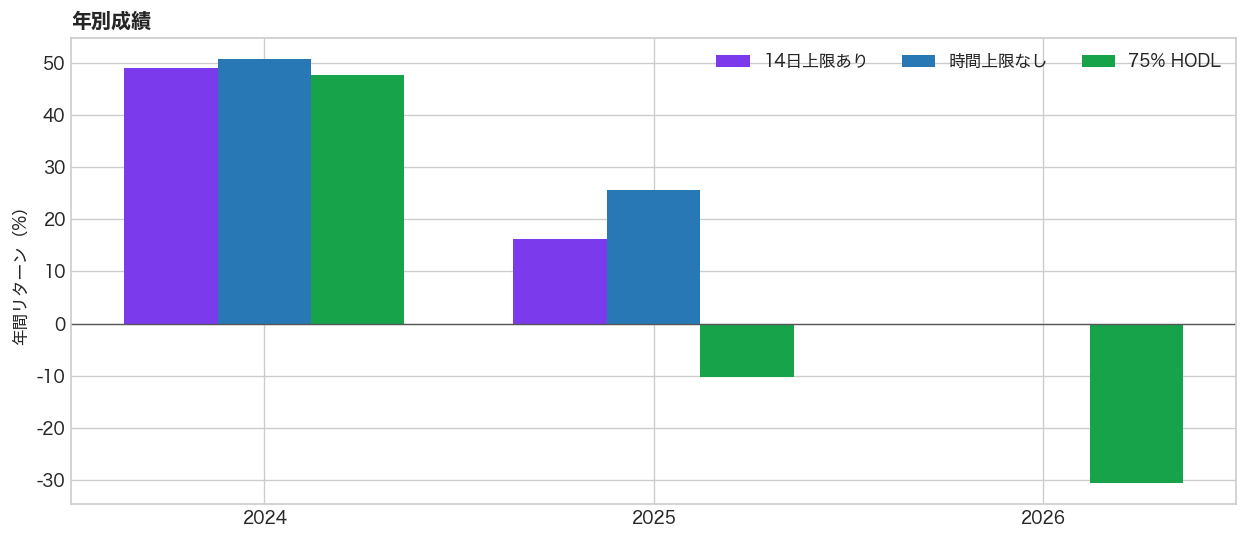

In [9]:
def yearly_return(series, label):
    daily_series = series.tz_convert(TZ).resample("1D").last().dropna()
    previous = CAPITAL
    rows = []
    for year, group in daily_series.groupby(daily_series.index.year):
        ending = float(group.iloc[-1])
        rows.append({"仕様": label, "年": int(year), "年間リターン%": (ending / previous - 1) * 100})
        previous = ending
    return rows


yearly = pd.DataFrame(
    yearly_return(adopted["equity"], "14日上限あり")
    + yearly_return(baseline["equity"], "時間上限なし")
    + yearly_return(hodl, "75% HODL")
)
year_table = yearly.pivot(index="年", columns="仕様", values="年間リターン%")
year_table = year_table[["14日上限あり", "時間上限なし", "75% HODL"]]
display(year_table.round(2))

fig, ax = plt.subplots(figsize=(10.5, 4.6))
x = np.arange(len(year_table))
width = 0.24
for offset, column, color in [
    (-1, "14日上限あり", "#7c3aed"),
    (0, "時間上限なし", "#2878b5"),
    (1, "75% HODL", "#16a34a"),
]:
    ax.bar(x + offset * width, year_table[column], width, label=column, color=color)
ax.axhline(0, color="#555", lw=0.8)
ax.set_xticks(x, year_table.index.astype(str))
ax.set_ylabel("年間リターン（%）")
ax.set_title("年別成績", loc="left", weight="bold")
ax.legend(ncol=3)
plt.tight_layout()
plt.show()


## 8. 判定

### 開発期間では評価基準を達成

- 累積リターン：+73.20%（75% HODLは−7.99%）
- 最大ドローダウン：−14.30%（基準20%以内）

ただし、すべて開発期間の結果です。仮説は暫定的に支持とし、未使用期間での再現を確認します。


## 9. 実運用の判定

### 本番運用は保留、固定ルールでフォワード観測

```text
開発期間の評価基準を達成
≠
実運用可能
```

**保留理由**

- サンプル数が少ない
- 指値の板順序や部分約定をOHLCVから完全には再現できない状況での検証



## 10. 次の検証

急上昇時のみに売り買いするbotをつくりたい

<div style="break-before: page; page-break-before: always;"></div>

---
## 免責事項

* 本資料は教育・情報提供を目的としており、売買を推奨するものではありません。
* バックテスト結果は過去データに基づく試算であり、将来の成果を保証しません。
* 暗号資産は大きく価格変動する可能性があります。
* 手数料、スリッページ、税金、約定遅延、データ訂正等を完全には反映していません。
* ETF Flowデータは公開時刻・訂正・取得可能性によって実運用上の利用可否が変わります。
* 本資料の利用により生じたいかなる損害についても責任を負いません。


<div style="break-before: page; page-break-before: always;"></div>

---
## アナウンス
botter会（ = ほへとさんレビュー会）

* 一期生（検証シーズン）決定
   * 9/10,17,24,10/1(予備) canaさん
   * 10/8,25,22,29(予備) shioriさん
   * 11/5,12,19,26(予備) muranoさん

※ 二期生から本格運用（募集）予定
